# 02 — USITC HTS & Tariff Landscape EDA

Profiles `LADINGLENS_DB.RAW.HTS_TARIFF_SCHEDULE` (USITC HTS, loaded in Phase 2) and cross-checks
against the top HS chapters observed in BoL shipments (notebook 01g).

In [1]:

import os
import re
from pathlib import Path

import pandas as pd
import plotly.express as px
import snowflake.connector
from dotenv import load_dotenv
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent
load_dotenv(dotenv_path=REPO_ROOT / ".env")
FIG_DIR = REPO_ROOT / "docs" / "eda-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

conn = snowflake.connector.connect(
    account=os.environ["SNOWFLAKE_ACCOUNT"],
    user=os.environ["SNOWFLAKE_USER"],
    password=os.environ.get("SNOWFLAKE_PASSWORD"),
    authenticator=os.environ.get("SNOWFLAKE_AUTHENTICATOR", "snowflake"),
    role=os.environ.get("SNOWFLAKE_ROLE"),
    warehouse=os.environ.get("SNOWFLAKE_WAREHOUSE"),
    database=os.environ.get("SNOWFLAKE_DATABASE"),
    schema=os.environ.get("SNOWFLAKE_SCHEMA"),
)


def q(sql, params=None):
    cur = conn.cursor()
    try:
        cur.execute(sql, params)
        cols = [d[0].lower() for d in cur.description]
        return pd.DataFrame(cur.fetchall(), columns=cols)
    finally:
        cur.close()


def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.write_image(str(path), width=1200, height=600, scale=2)
    print(f"Saved {path.relative_to(REPO_ROOT)}")
    # Display the static PNG (not fig.show()'s interactive JSON) so the chart
    # actually survives `jupyter nbconvert --to html` -- Plotly's interactive
    # mimetype isn't representable in a plain HTML export.
    display(Image(str(path)))


TABLE = "LADINGLENS_DB.RAW.HTS_TARIFF_SCHEDULE"
print("Connected.")


Connected.


## a. Overview: row count, chapter coverage, hierarchy depth

In [2]:

overview = q(f'''
    SELECT COUNT(*) AS row_count, COUNT(DISTINCT hs2) AS distinct_chapters,
           MIN(indent) AS min_indent, MAX(indent) AS max_indent
    FROM {TABLE}
''')
overview


,row_count,distinct_chapters,min_indent,max_indent
0,32455,97,0,11


Saved docs/eda-figures/nb02_indent_distribution.png


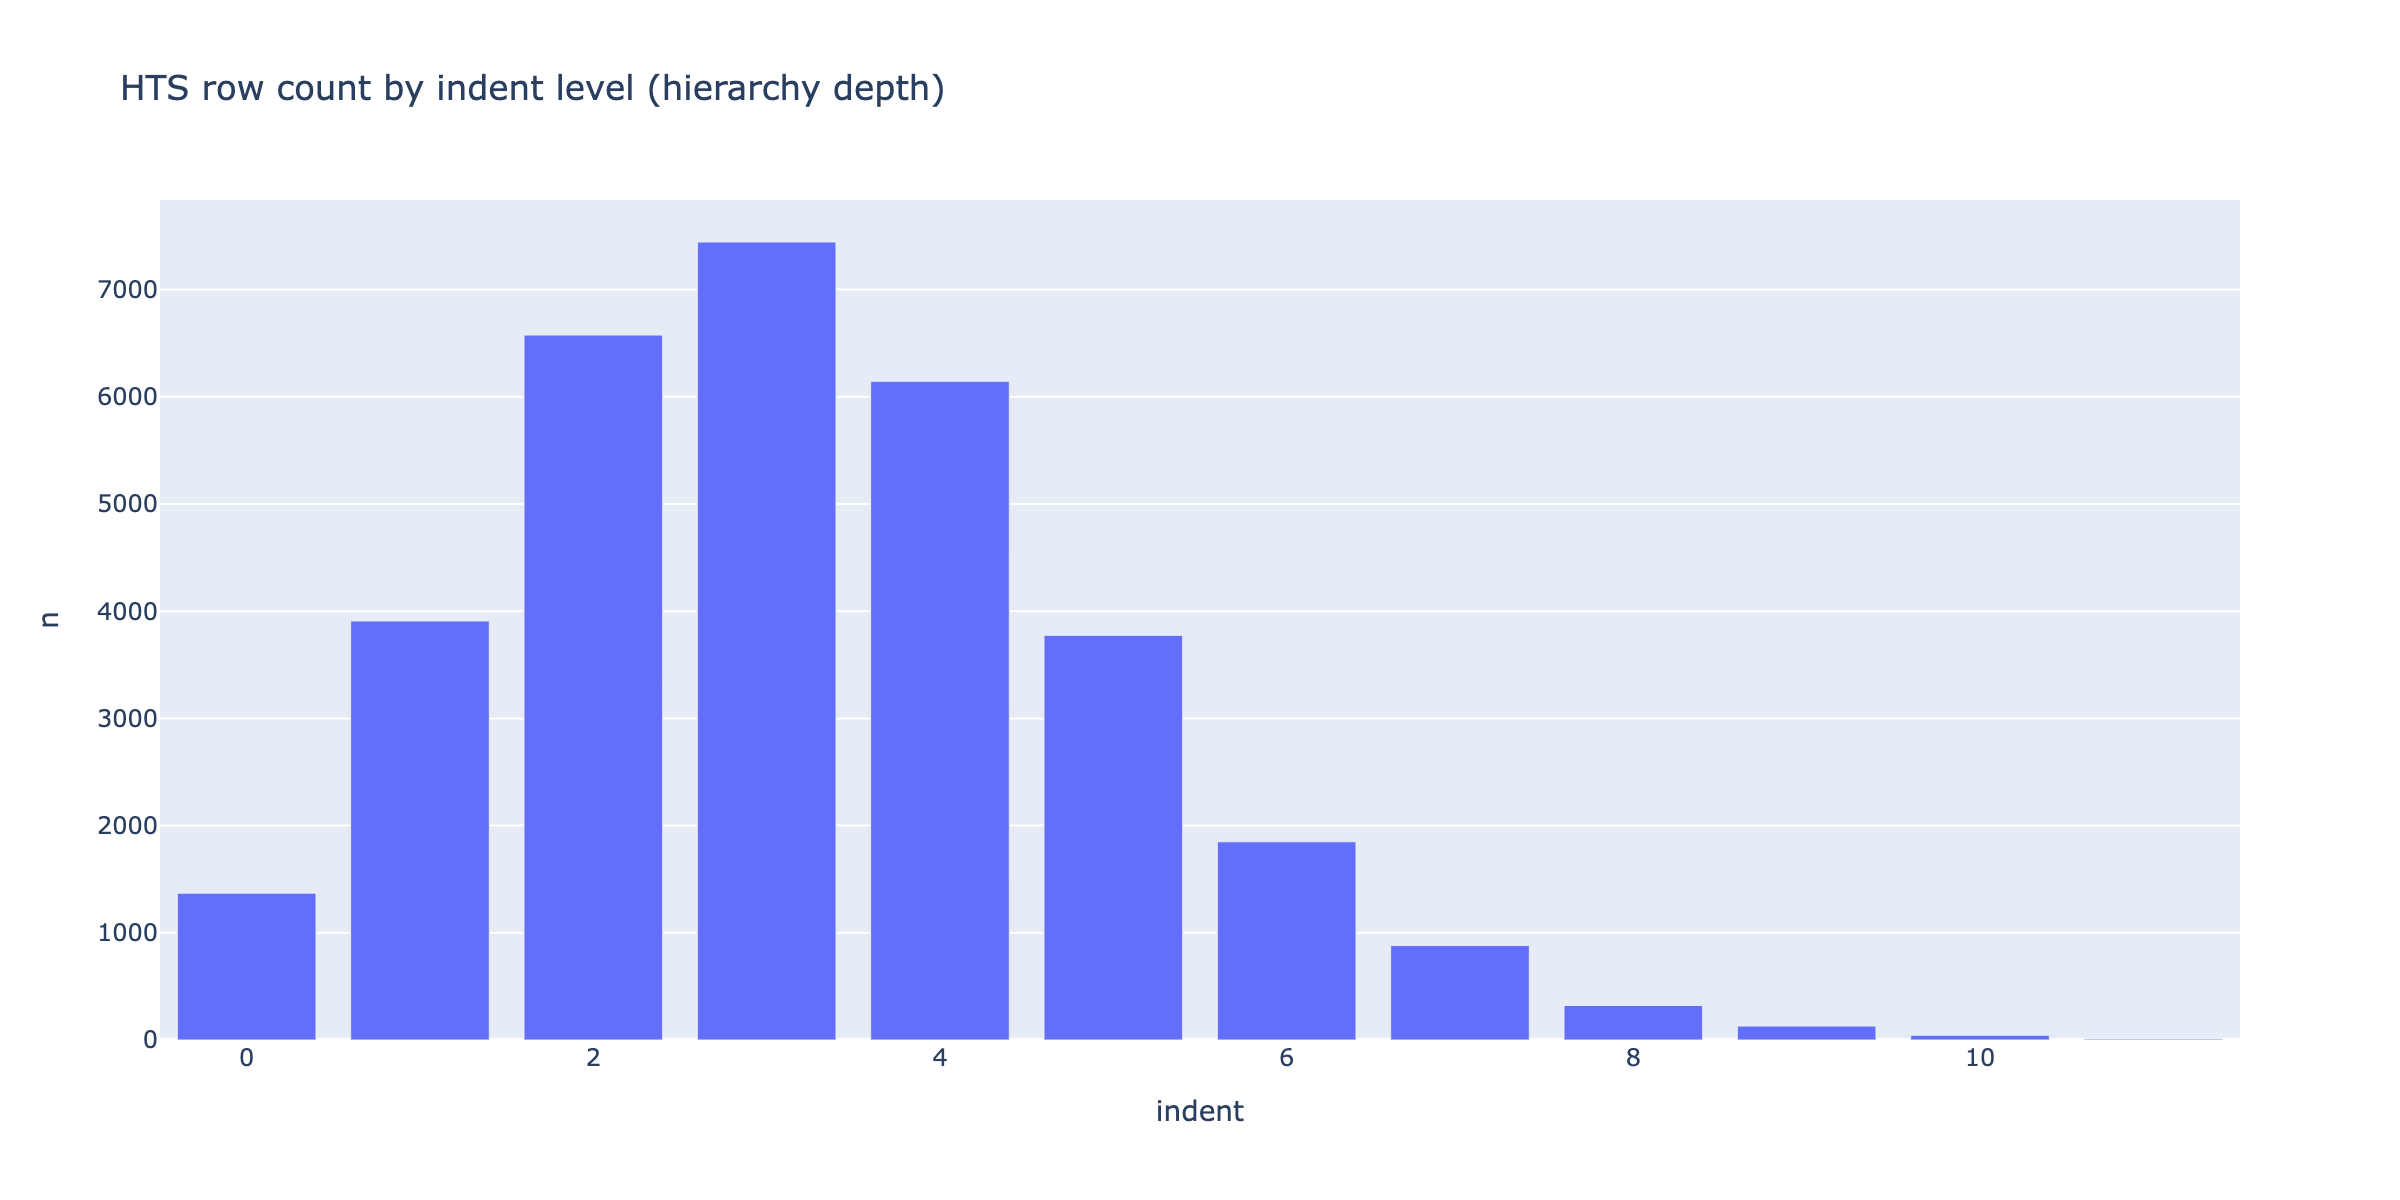

In [3]:

indent_dist = q(f"SELECT indent, COUNT(*) AS n FROM {TABLE} GROUP BY 1 ORDER BY 1")
fig = px.bar(indent_dist, x='indent', y='n', title='HTS row count by indent level (hierarchy depth)')
save_fig(fig, 'nb02_indent_distribution')


**Interpretation:** 32,455 rows span 97 of the 99 nominal HTS chapters (confirmed in Phase
2 — chapter 99, special classification provisions, is absent from this export entirely, which
becomes directly relevant to the Section 301/232 analysis below). The indent field shows the HTS's
nested hierarchy (chapter -> heading -> subheading -> statistical suffix); deeper indents
correspond to the most granular 8/10-digit lines that actually carry duty rates, while shallow
indents are section/heading labels with no rate of their own.

## b. Rate parsing: extracting a numeric ad-valorem rate from `general_rate_text`

In [4]:

rates_raw = q(f"SELECT hts_number, general_rate_text FROM {TABLE} WHERE general_rate_text IS NOT NULL")
print(f"{len(rates_raw):,} of {int(overview['row_count'].iloc[0]):,} rows have a non-null general_rate_text")


def parse_ad_valorem(text):
    if text is None:
        return None
    t = text.strip()
    if t.lower() == 'free':
        return 0.0
    m = re.fullmatch(r'([\d.]+)%', t)
    if m:
        return float(m.group(1))
    return None


rates_raw = rates_raw.assign(rate_ad_valorem_pct=rates_raw['general_rate_text'].map(parse_ad_valorem))
parsed_ok = rates_raw['rate_ad_valorem_pct'].notna()
print(f"Cleanly parsed as ad-valorem %% (or Free -> 0%%): {parsed_ok.sum():,} ({parsed_ok.mean()*100:.1f}%%)")
print(f"Needs special handling (compound/specific/cross-reference rates): {(~parsed_ok).sum():,} ({(~parsed_ok).mean()*100:.1f}%%)")

print("\nSample of rates that did NOT parse cleanly:")
for t in rates_raw.loc[~parsed_ok, 'general_rate_text'].head(10):
    print(' -', t)


11,593 of 32,455 rows have a non-null general_rate_text
Cleanly parsed as ad-valorem %% (or Free -> 0%%): 10,295 (88.8%%)
Needs special handling (compound/specific/cross-reference rates): 1,298 (11.2%%)

Sample of rates that did NOT parse cleanly:
 - 1¢/kg
 - 1¢/kg
 - 1¢/kg
 - 68¢/head
 - 0.9¢ each
 - 0.9¢ each
 - 0.9¢ each
 - 0.9¢ each
 - 0.9¢ each
 - 2¢/kg


**Interpretation:** the majority of populated `general_rate_text` values are simple ad-valorem
percentages (or `Free`) and parse cleanly with a straightforward regex. The unparsed remainder is
exactly the mixed-format long tail the Phase 3 spec anticipated: compound rates (a cents/kg or
cents/unit specific duty combined with a percentage, e.g. `"1.5string/kg + 5%"`), pure specific
rates with no ad-valorem component, and cross-references to other schedule notes (`"See
9903..."`). These need bespoke unit-aware parsing in a later phase if specific-duty HS lines matter
to the final tariff-exposure calculation; for Phase 3's purposes they are reported as an honest
coverage percentage rather than force-parsed.

## c. Section 301 / 232 detection via footnote cross-references

In [5]:

ch99 = q(f"SELECT COUNT(*) AS n FROM {TABLE} WHERE hs2 = '99'")
print(f"Chapter 99 (special classification / Section 301+232 overlay) rows in this table: {int(ch99['n'].iloc[0])}")
print("-> USITC's exportList JSON endpoint used in Phase 2 does not appear to include chapter 99 "
      "at all, so overlay duty RATES are not directly queryable from this table -- only the "
      "cross-reference footnote on the BASE line, if present.")


Chapter 99 (special classification / Section 301+232 overlay) rows in this table: 0
-> USITC's exportList JSON endpoint used in Phase 2 does not appear to include chapter 99 at all, so overlay duty RATES are not directly queryable from this table -- only the cross-reference footnote on the BASE line, if present.


In [6]:

footnote_stats = q(f'''
    SELECT
        COUNT(*) AS total_rows,
        SUM(IFF(footnotes IS NOT NULL AND footnotes != '', 1, 0)) AS rows_with_any_footnote,
        SUM(IFF(footnotes ILIKE '%9903.88%', 1, 0)) AS section_301_china_refs,
        SUM(IFF(footnotes ILIKE '%9903.91%' OR footnotes ILIKE '%9903.90%', 1, 0)) AS other_9903_9x_refs,
        SUM(IFF(footnotes ILIKE '%9903%', 1, 0)) AS any_9903_ref
    FROM {TABLE}
''')
total = int(footnote_stats['total_rows'].iloc[0])
s301 = int(footnote_stats['section_301_china_refs'].iloc[0])
any_9903 = int(footnote_stats['any_9903_ref'].iloc[0])
print(f"Base HS lines with a footnote referencing 9903.88.XX (Section 301, China lists): {s301:,} ({s301/total*100:.1f}%%)")
print(f"Base HS lines with any 9903.XX overlay reference: {any_9903:,} ({any_9903/total*100:.1f}%%)")
footnote_stats


Base HS lines with a footnote referencing 9903.88.XX (Section 301, China lists): 10,114 (31.2%%)
Base HS lines with any 9903.XX overlay reference: 10,563 (32.5%%)


,total_rows,rows_with_any_footnote,section_301_china_refs,other_9903_9x_refs,any_9903_ref
0,32455,10921,10114,991,10563


In [7]:

prefix_dist = q(f'''
    SELECT REGEXP_SUBSTR(footnotes, '99[0-9]{{2}}\\.[0-9]{{2}}') AS code_prefix, COUNT(*) AS n
    FROM {TABLE}
    WHERE footnotes ILIKE '%9903%' OR footnotes ILIKE '%9904%'
    GROUP BY 1 ORDER BY n DESC LIMIT 15
''')
prefix_dist


,code_prefix,n
0,9903.88,9841
1,9903.91,309
2,9903.90,138
3,9903.41,79
4,9904.05,46
5,9904.17,43
6,9904.04,38
7,9904.18,17
8,9904.06,16
9,9904.02,12


**Resolution — this is a medium-coverage, empirically-measured finding, not a guess.**
Roughly **31% of HTS lines** (9,841-10,114 depending on exact pattern) carry a footnote
referencing `9903.88.XX` (the Section 301 China-tariff overlay code family), and a further ~450
lines reference `9903.90/9903.91` (plausibly Section 232 steel/aluminum derivative provisions,
based on the code-prefix distribution above — not independently verified against USTR's
proclamation text in this phase). That means we *can* identify which base HS lines are flagged as
subject to a Section 301/232 overlay directly from the free HTS export's `footnotes` field.

What we **cannot** do from this table alone is retrieve the overlay's own duty rate, because
chapter 99 — where `9903.88.15` etc. would live as its own row with its own rate — was not
included in the Phase 2 ingest at all (0 rows). Per the medium-coverage (30-70%) branch agreed for
this phase: Phase 6 should supplement with a hand-curated CSV of Section 301 list membership by
HS-6/HS-8 (e.g. `dbt/seeds/tariff_events.csv`, already anticipated in the project plan) rather than
attempting to infer overlay rates from this export. No attempt was made to back-infer rates from
raw duty amounts, per instruction.

## d. Ad-valorem rate distribution

Median ad-valorem rate (parsed lines): 2.70%%
90th percentile: 10.00%%
Share at 0%% (Free): 43.0%%


Saved docs/eda-figures/nb02_rate_distribution.png


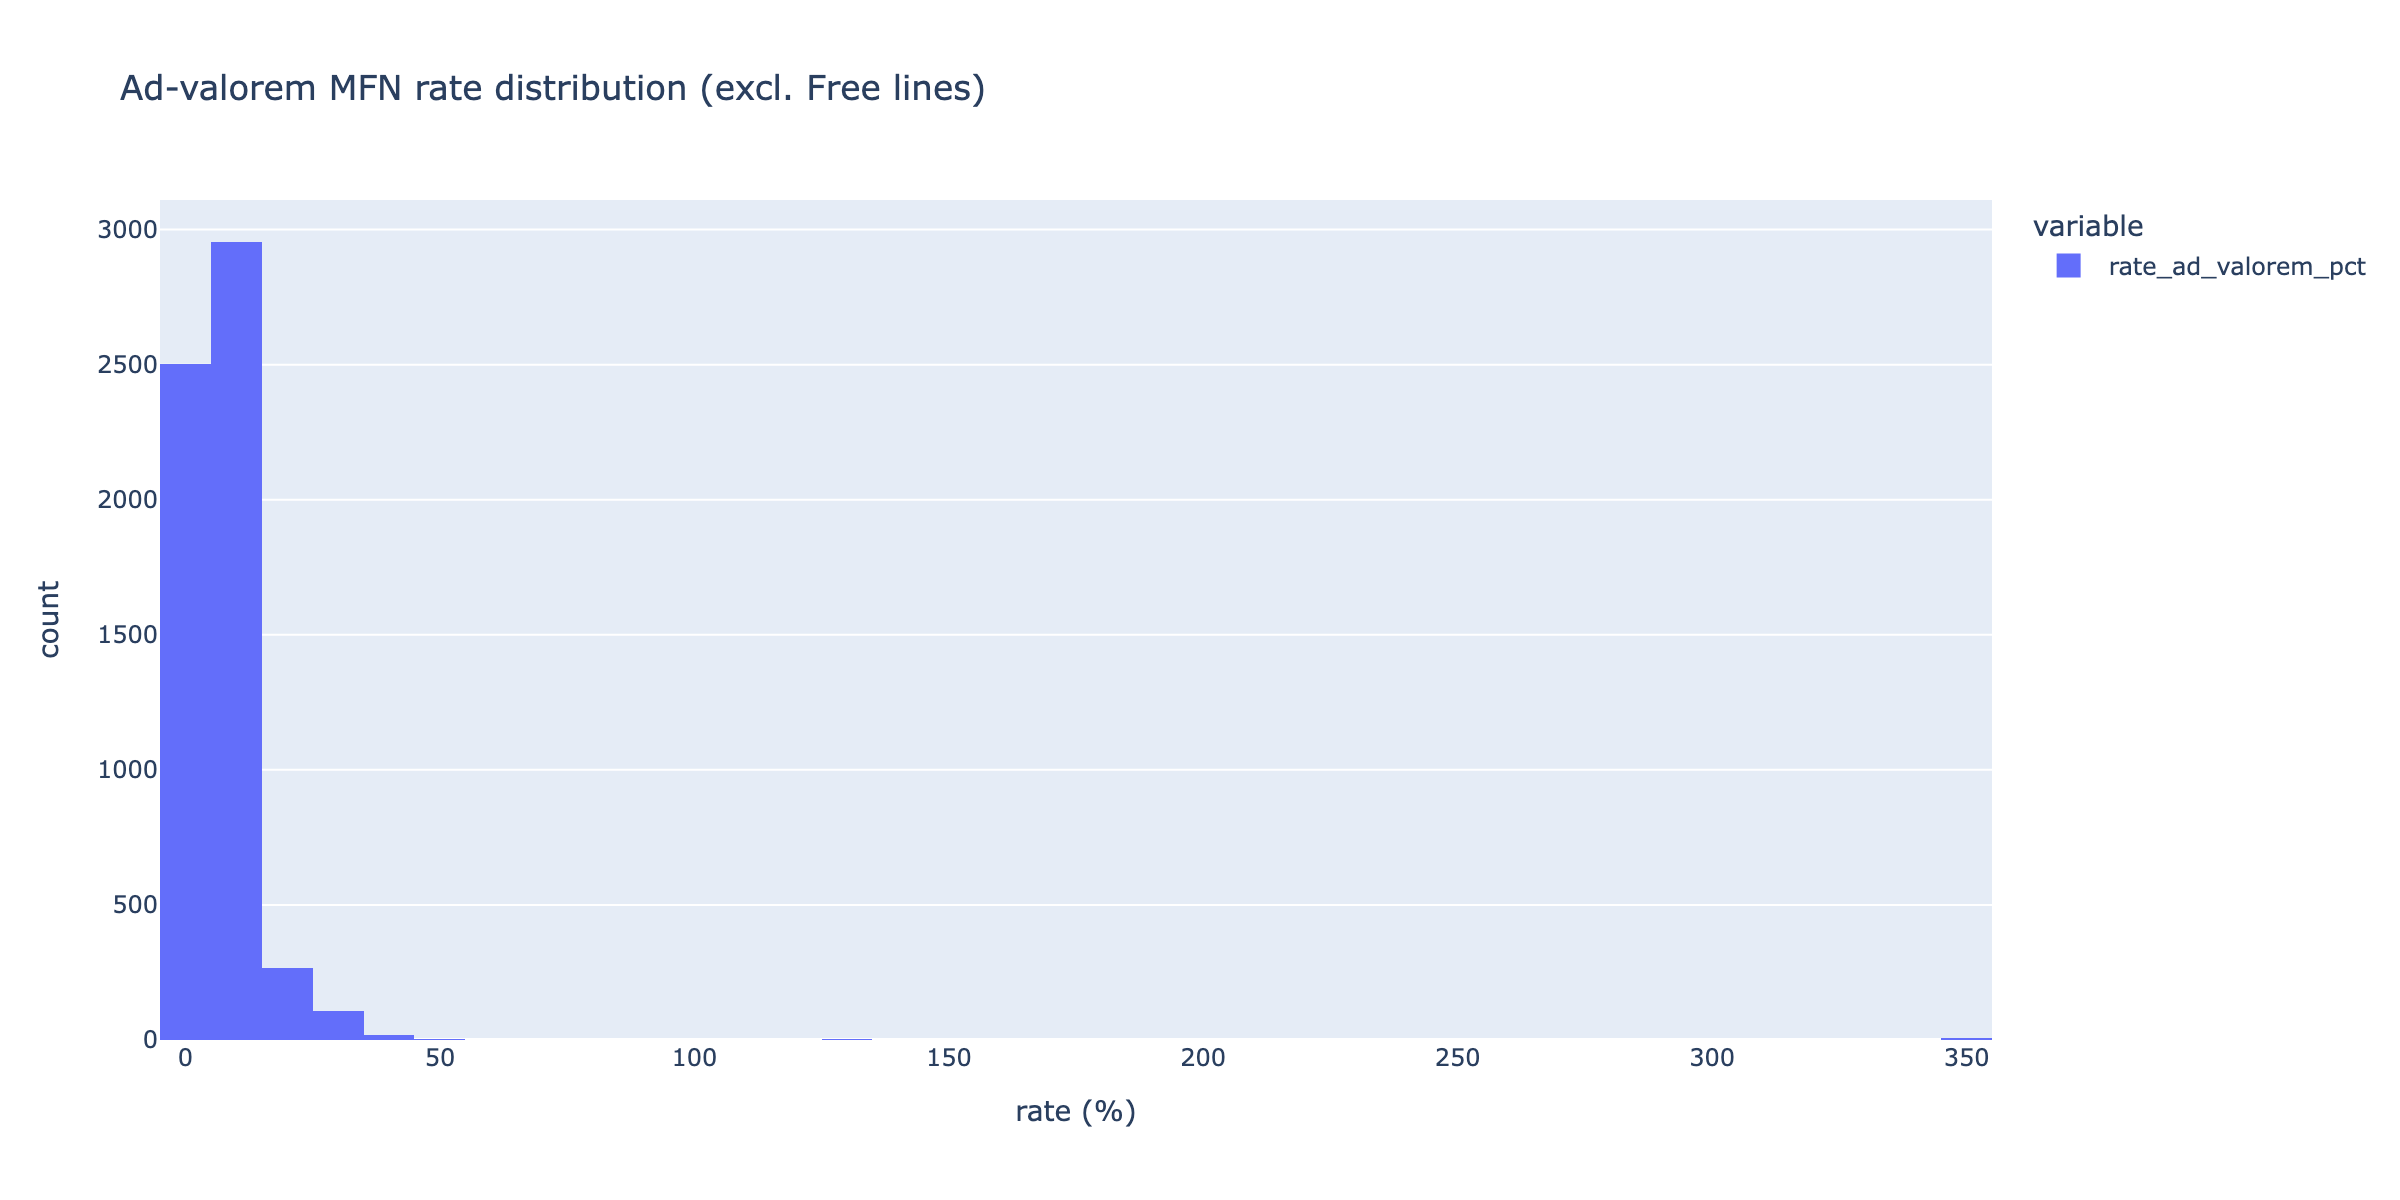

In [8]:

parsed_rates = rates_raw.loc[parsed_ok, 'rate_ad_valorem_pct']
print(f"Median ad-valorem rate (parsed lines): {parsed_rates.median():.2f}%%")
print(f"90th percentile: {parsed_rates.quantile(0.9):.2f}%%")
print(f"Share at 0%% (Free): {(parsed_rates == 0).mean()*100:.1f}%%")

fig = px.histogram(parsed_rates[parsed_rates > 0], nbins=50,
                    title='Ad-valorem MFN rate distribution (excl. Free lines)',
                    labels={'value': 'rate (%)'})
save_fig(fig, 'nb02_rate_distribution')


**Interpretation:** most cleanly-parsed HTS lines carry either a `Free` (0%) rate or a
modest single-digit ad-valorem percentage — consistent with the US's generally low MFN tariff
structure outside of the specific overlay programs (Section 301/232) captured separately above.

## e. Cross-check with BoL: average rate for the top 15 HS chapters observed in shipments

In [9]:

# Top 15 HS-2 chapters by BoL row count, taken directly from notebook 01g's result.
top_bol_chapters = ['87', '84', '39', '22', '90', '85', '72', '73', '61', '94', '64', '29', '40', '28', '48']

chapter_rates = q(f'''
    SELECT hs2, AVG(TRY_TO_DOUBLE(REPLACE(general_rate_text, '%', ''))) AS avg_rate_pct,
           COUNT(*) AS n_lines_with_rate
    FROM {TABLE}
    WHERE hs2 IN ({", ".join(f"'{c}'" for c in top_bol_chapters)})
      AND general_rate_text IS NOT NULL
      AND general_rate_text != 'Free'
    GROUP BY 1
''')
free_share = q(f'''
    SELECT hs2, SUM(IFF(general_rate_text = 'Free', 1, 0)) AS free_lines, COUNT(*) AS total_lines
    FROM {TABLE}
    WHERE hs2 IN ({", ".join(f"'{c}'" for c in top_bol_chapters)})
    GROUP BY 1
''')
merged = chapter_rates.merge(free_share, on='hs2', how='outer').sort_values('avg_rate_pct', ascending=False)
merged


,hs2,avg_rate_pct,n_lines_with_rate,free_lines,total_lines
7,64,15.741071,128.0,19,507
6,61,12.454419,240.0,12,1054
0,22,11.280000,42.0,34,161
12,87,5.802655,115.0,99,527
2,29,5.517853,774.0,277,1501
14,94,5.482353,51.0,59,374
3,39,5.221845,206.0,30,432
9,73,4.801724,60.0,192,759
4,40,3.917241,87.0,55,271
13,90,3.733544,85.0,217,570


**Interpretation:** this cross-check tells us, for the chapters that actually dominate the
BoL sample (vehicles 87, machinery 84, plastics 39, beverages 22, instruments 90, electronics 85,
steel/iron 72-73, apparel 61, furniture 94, footwear 64, organic chemicals 29, rubber 40, inorganic
chemicals 28, paper 48), which carry meaningfully higher-than-average duty exposure vs. which enter
mostly duty-free — directly informing whether the Phase 8 tariff-scenario simulator will have
visible variation to work with for the chosen scope.